In [3]:
using Plots
include("../sampled_integrals.jl")

reduced_tensor_grid (generic function with 1 method)

In [4]:
# Function to calculate the number of cavity terms at a cavity order
function number_of_cavity_terms_by_order(cavity_order::Int)::Vector{Int}
    # terms_at_any_order
    terms_at_order::Vector{Int} = floor.(Int, collect(0:cavity_order)/2) .+1
    return terms_at_order
end

function how_many_geq_combinations(len::Int, sample_num::Int)
    # How many combinations of length len are there with integers between 1 and sample_num ordered by size, i.e. [1,1,2] but not [1,2,1]
    # this is the size of a multiset 
    comb::Int = binomial(len+sample_num-1, len)
    return comb
end

function sum_to_n(n::Int, len::Int)::Vector{Vector{Int}}
    # A function that constructs the different ways for a vector of length len to sum up to n, i.e. for n=2 and len=3: [1,1,0], [1,0,1], [0,1,1], [2,0,0], [0,2,0], [0,0,2]
    # construct the different ways to sum up len Integers to n
    if len == 1
        return [[n]]
    end
    all_sums::Vector{Vector{Int}} = Vector{Vector{Int}}()
    for i in 0:n
        for sum in sum_to_n(n-i, len-1)
            push!(all_sums, [i; sum])
        end
    end
    return all_sums
end	

function number_of_spin_terms_by_order(spin_order::Int, sample_num::Int)::Vector{Int}
    # How many terms are there at a given order for a given number of samples
    # get how_many_geq_combinations from len=0 up to up to spin_order 
    combinations::Vector{Int} = [how_many_geq_combinations(len, sample_num) for len in 0:spin_order]
    # get the sum_to_n for each n at len=3 (x,y,z)
    all_sums::Vector{Vector{Vector{Int}}} = Vector{Vector{Vector{Int}}}(undef, spin_order+1)
    curr_comb::Vector{Vector{Int}} = Vector{Vector{Int}}()
    for i in 0:spin_order
        curr_comb = sum_to_n(i, 3)
        all_sums[i+1] = Vector{Vector{Int}}()
        for comb in curr_comb
            push!(all_sums[i+1], comb)
        end
    end
    how_many_terms::Vector{Int} = zeros(Int, length(all_sums))
    for (i, comb) in enumerate(all_sums)
        for c in comb
            how_many_terms[i] += prod(combinations[c .+ 1])
        end
    end
    return how_many_terms
end
function calculate_number_of_terms_by_order(max_order::Int, sample_num::Int)::Vector{Int}
    # Calculate the number of terms in the equations
    # spin_order: order of spin operators
    # cavity_order: order of cavity operators
    # sample_num: number of samples
    # returns: number of terms
    how_many_spin_terms = number_of_spin_terms_by_order(max_order, sample_num)
    how_many_cavity_terms = number_of_cavity_terms_by_order(max_order)
    how_many_terms::Vector{Int} = zeros(Int, max_order)
    for order in 1:max_order
        for spin_order in 0:order
            cavity_order = order - spin_order
            how_many_terms[order] += how_many_spin_terms[spin_order+1]*how_many_cavity_terms[cavity_order+1]
        end
    end
    return how_many_terms
end
function calculate_number_of_terms(max_order::Int, sample_num::Int)
    # Calculate the number of terms in the equations
    # spin_order: order of spin operators
    # cavity_order: order of cavity operators
    # sample_num: number of samples
    # returns: number of terms
    return sum(calculate_number_of_terms_by_order(max_order, sample_num))
end
# Test 
calculate_number_of_terms_by_order(3, 4)

3-element Vector{Int}:
  13
  92
 468

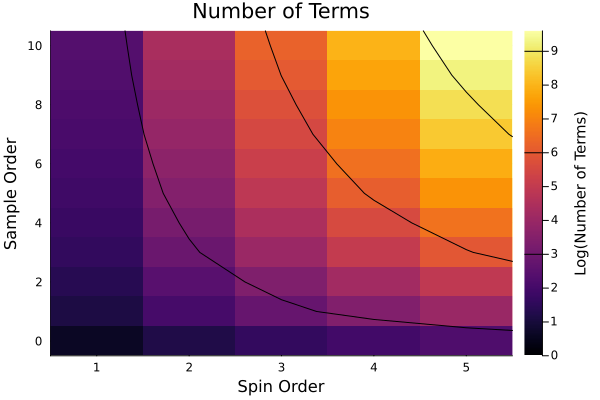

In [5]:
g0 = 2*pi*150/10^6  # 150Hz
delta_g = g0*0.20
delta0 = 0.0
delta_delta = 2*pi*0.1 # 100kHz 
sigmas = 3
N = 10^6

gaussian = (x, mu, sigma) -> exp(-(x-mu)^2/sigma^2/2)*1/sqrt(2*pi*sigma^2)
prob_fun_vec = [x -> gaussian(x, g0, delta_g), x -> gaussian(x, delta0, delta_delta)]
fun_vec = [x -> x*N*gaussian(x, g0, delta_g), x -> gaussian(x, delta0, delta_delta)] # g integral times g
range_vec = [[g0-sigmas*delta_g, g0+sigmas*delta_g], [-delta_delta*sigmas, delta_delta*sigmas]]


sample_orders::Vector{Int} = collect(0:11)
orders::Vector{Int} = collect(1:6)
samples_by_sample_order::Vector{Int} = Vector{Int}()
for sample_order in sample_orders
    if sample_order == 0
        push!(samples_by_sample_order, 1)
        continue
    end
    locations, order_comb, centers = sample_grid(prob_fun_vec, range_vec, sample_order; extra_points=0, symmetrize=true, reposition=true, on_borders=false, equidistant=true)
    push!(samples_by_sample_order, length(locations))
end
terms_by_order = Array{Int}(undef, length(sample_orders), length(orders))
for order in orders
    for (i, sample_order) in enumerate(sample_orders)
        terms_by_order[i, order] = calculate_number_of_terms(order, samples_by_sample_order[i])
    end
end
# Plot spin_orders_by_order as 2d colormap of spin_order vs sample_order
plt = plot()
# make the colormap logarithmic 
log_terms_by_order = log10.(terms_by_order)
heatmap!(plt, orders, sample_orders, log_terms_by_order, title="Number of Terms", ylabel="Sample Order", xlabel="Spin Order", colorbar_title="Log(Number of Terms)")
# add contour lines where log_spin_terms_by_order becomes 3, 6, 9
contour!(plt, orders, sample_orders, log_terms_by_order, levels=[3, 6, 9], color=:black)
plot!(plt, yticks=collect(0:2:10), xlims=[0.5,5.5], ylims=[-0.5,10.5], clims=(0,log_terms_by_order[11,5]))
display(plt)